In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "processed_startup_data.csv"
)

In [2]:
from sklearn.model_selection import train_test_splitpgtrffdkjnbvfc
X_no_revenue = df.drop(
    columns=[
        "unicorn",
        "estimated_revenue_usd"
    ]
)

y = df["unicorn"]



X_train, X_test, y_train, y_test = train_test_split(
    X_no_revenue,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40000, 31)
(10000, 31)
(40000,)
(10000,)


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9034
Precision: 0.9196528208307502
Recall   : 0.9588881706528766
F1 Score : 0.9388607594936709
ROC AUC  : 0.95210509267385


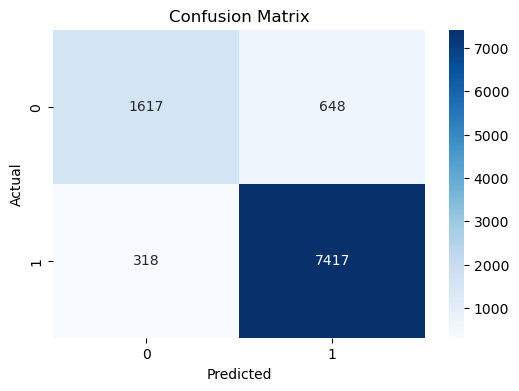

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [8]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.71      0.77      2265
           1       0.92      0.96      0.94      7735

    accuracy                           0.90     10000
   macro avg       0.88      0.84      0.85     10000
weighted avg       0.90      0.90      0.90     10000



In [9]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,funding_amount_usd,0.630874
2,employee_count,0.057466
7,country_freq,0.048735
3,funding_year,0.032931
4,funding_month,0.032606
0,founded_year,0.028644
5,startup_age,0.028434
6,investor_count,0.014902
22,funding_round_Series B,0.006835
21,funding_round_Series A,0.006472


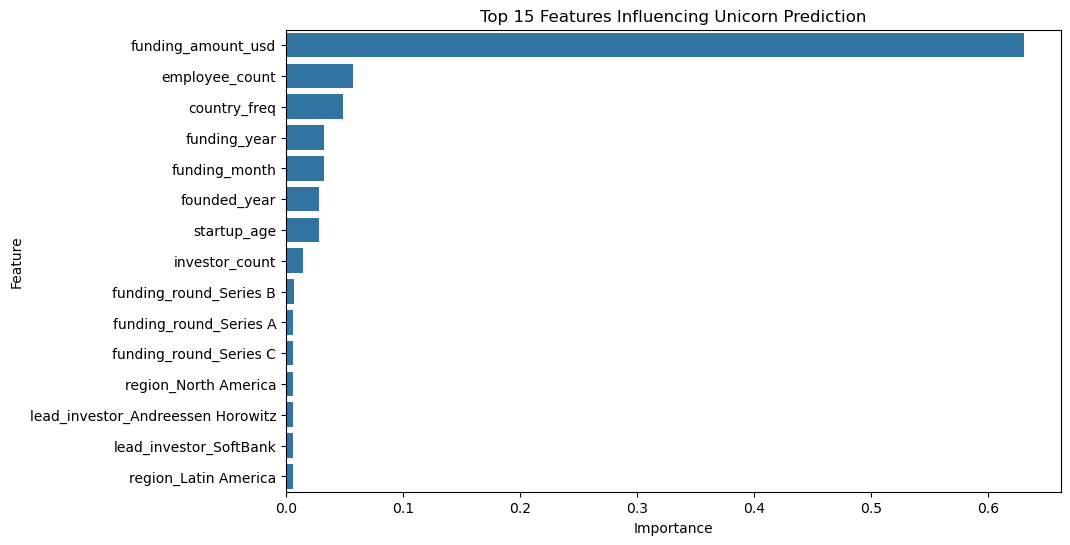

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Unicorn Prediction")

plt.show()

In [11]:
feature_importance.head(10)

,Feature,Importance
1,funding_amount_usd,0.630874
2,employee_count,0.057466
7,country_freq,0.048735
3,funding_year,0.032931
4,funding_month,0.032606
0,founded_year,0.028644
5,startup_age,0.028434
6,investor_count,0.014902
22,funding_round_Series B,0.006835
21,funding_round_Series A,0.006472
